# Generation, oversampling, and traceability

Generate synthetic rows and inspect their trace records.

In [1]:
import sys
from pathlib import Path

from IPython.display import display

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
if NOTEBOOK_DIR.exists() and str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from mimic import MIMIC
from mimic_notebook_utils import (
    append_generated_rows,
    cell_sampling_trace,
    class_balance,
    generated_embedding_trace,
    identity_generation_plot,
    make_two_spiral_frame,
    plot_oversampling,
)

MAJORITY_SAMPLES = 250
MINORITY_SAMPLES = MAJORITY_SAMPLES // 2

df = make_two_spiral_frame(
    majority_samples=MAJORITY_SAMPLES,
    minority_samples=MINORITY_SAMPLES,
    random_state=2,
)

display(class_balance(df).style.set_caption("Original class balance"))
display(df.head(8).style.set_caption("Original two-spiral training rows"))


,count
label,
majority,250
minority,125


,x,y,label,id
0,0.247798,0.090811,majority,0
1,0.168761,0.206043,majority,1
2,0.186642,0.008847,majority,2
3,-0.053813,0.116717,majority,3
4,0.456219,0.104372,majority,4
5,0.376696,0.070445,majority,5
6,0.197465,0.467894,majority,6
7,0.324404,0.371906,majority,7


In [2]:
mimic = MIMIC(
    columns={
        "ignore": ["id"],
        "regression": ["x", "y"],
        "classification": ["label"],
    },
    mode="factorised", # modes: "identity", "direct", "factorised", "joint"
    capacity=0.25,
    random_state=2,
)
mimic.fit(df)
synthetic, trace = mimic.sample(12, return_trace=True)

display(generated_embedding_trace(synthetic, trace).head(8).style.set_caption("Generated rows with embedding trace"))
display(cell_sampling_trace(trace).head(12).style.set_caption("Per-cell stochastic sampling trace"))


,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,decoder
0,1.612833,-1.839114,minority,314.000000,316.000000,317.000000,0.399246,mutual,NeuralConditionalSampler
1,-0.579193,-1.802830,minority,305.000000,303.000000,304.000000,0.550050,mutual,NeuralConditionalSampler
2,-0.875477,-2.279373,minority,304.000000,306.000000,304.000000,0.343951,mutual,NeuralConditionalSampler
3,-0.072442,0.404269,majority,20.000000,17.000000,15.000000,0.578717,mutual,NeuralConditionalSampler
4,1.383481,1.535898,majority,114.000000,115.000000,119.000000,0.325031,mutual,NeuralConditionalSampler
5,-2.299906,-1.346523,majority,162.000000,157.000000,161.000000,0.461392,mutual,NeuralConditionalSampler
6,0.916734,-1.331818,majority,82.000000,83.000000,82.000000,0.733718,mutual,NeuralConditionalSampler
7,-0.081773,-0.199263,minority,256.000000,257.000000,258.000000,0.343626,mutual,NeuralConditionalSampler


,trace_type,sample_index,method,decoder,generation_decode_mode,resolved_generation_decode_mode,sweep,column,task,sampled_value,conditioning,embedding_slice_start,embedding_slice_stop,member_index,component_index,component_probability,component_mean,component_sigma,sample_log_probability,sampled_class_code,class_probabilities
12,cell,0,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,1.925036,z_minus_j,0.000000,33.000000,1.000000,2.000000,0.177167,1.089792,0.064998,-0.369488,nan,nan
13,cell,1,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-0.608557,z_minus_j,0.000000,33.000000,1.000000,2.000000,0.281515,-0.411366,0.072804,1.785229,nan,nan
14,cell,2,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-0.955458,z_minus_j,0.000000,33.000000,1.000000,1.000000,0.591349,-0.598936,0.059715,1.765838,nan,nan
15,cell,3,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-0.049648,z_minus_j,0.000000,33.000000,1.000000,1.000000,0.566472,0.014862,0.059895,1.079973,nan,nan
16,cell,4,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,1.297651,z_minus_j,0.000000,33.000000,1.000000,1.000000,0.393373,0.754557,0.082481,1.385674,nan,nan
17,cell,5,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-2.246448,z_minus_j,0.000000,33.000000,1.000000,1.000000,0.555288,-1.338412,0.083035,1.060208,nan,nan
18,cell,6,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,0.846558,z_minus_j,0.000000,33.000000,1.000000,1.000000,0.455084,0.536449,0.069018,1.348325,nan,nan
19,cell,7,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-0.172983,z_minus_j,0.000000,33.000000,1.000000,1.000000,0.572648,-0.113965,0.062036,1.741069,nan,nan
20,cell,8,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,0.017782,z_minus_j,0.000000,33.000000,1.000000,1.000000,0.564229,0.092360,0.055407,0.141799,nan,nan
21,cell,9,gibbs_forest,NeuralConditionalSampler,auto,factorised,0.000000,x,regression,1.346964,z_minus_j,0.000000,33.000000,1.000000,0.000000,0.384870,0.688514,0.112445,0.687092,nan,nan


In [3]:
minority_needed = df["label"].value_counts()["majority"] - df["label"].value_counts()["minority"]
minority_synthetic, minority_trace = mimic.sample(
    minority_needed,
    condition={"label": "minority"},
    return_trace=True,
)
balanced = append_generated_rows(df, minority_synthetic)

display(class_balance(balanced).style.set_caption("Class balance after minority-conditioned displacement oversampling"))
display(generated_embedding_trace(minority_synthetic, minority_trace, include_condition=True).head(8).style.set_caption("Synthetic minority rows with embedding trace"))
display(cell_sampling_trace(minority_trace).head(12).style.set_caption("Minority per-cell stochastic sampling trace"))


,count
label,
majority,250
minority,250


,x,y,label,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,condition,decoder
0,-3.040452,-2.071188,minority,354.000000,352.000000,353.000000,0.399246,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
1,-3.085974,-0.889866,minority,351.000000,353.000000,354.000000,0.550050,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
2,-3.105674,-1.051098,minority,351.000000,350.000000,352.000000,0.343951,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
3,-0.326066,-0.252254,minority,256.000000,258.000000,255.000000,0.578717,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
4,-1.148824,1.048480,minority,288.000000,291.000000,293.000000,0.325031,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
5,-0.839318,-1.600545,minority,304.000000,306.000000,305.000000,0.461392,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
6,1.027477,0.833311,minority,277.000000,278.000000,282.000000,0.733718,mutual,"{""label"": ""minority""}",NeuralConditionalSampler
7,0.773593,2.903958,minority,335.000000,337.000000,338.000000,0.343626,mutual,"{""label"": ""minority""}",NeuralConditionalSampler


,trace_type,sample_index,method,condition,decoder,generation_decode_mode,resolved_generation_decode_mode,sweep,column,task,sampled_value,conditioning,embedding_slice_start,embedding_slice_stop,member_index,component_index,component_probability,component_mean,component_sigma,sample_log_probability
125,cell,0,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-3.323777,z_minus_j,0.000000,33.000000,1.000000,2.000000,0.437324,-1.958426,0.197931,-0.065961
126,cell,1,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-3.442436,z_minus_j,0.000000,33.000000,1.000000,2.000000,0.432229,-1.954750,0.182335,-0.459033
127,cell,2,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-3.010674,z_minus_j,0.000000,33.000000,1.000000,2.000000,0.432307,-1.945824,0.183612,0.503924
128,cell,3,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-0.027703,z_minus_j,0.000000,33.000000,1.000000,0.000000,0.169854,-0.073911,0.084998,1.252640
129,cell,4,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-1.048952,z_minus_j,0.000000,33.000000,1.000000,2.000000,0.295631,-0.635866,0.074419,1.651204
130,cell,5,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-1.078652,z_minus_j,0.000000,33.000000,1.000000,1.000000,0.591575,-0.608344,0.059501,1.185787
131,cell,6,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,0.877570,z_minus_j,0.000000,33.000000,1.000000,0.000000,0.303836,0.471564,0.097674,1.177428
132,cell,7,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,0.607658,z_minus_j,0.000000,33.000000,1.000000,1.000000,0.445436,0.481725,0.077022,0.002775
133,cell,8,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-1.297194,z_minus_j,0.000000,33.000000,1.000000,2.000000,0.317846,-0.854265,0.085957,1.630188
134,cell,9,gibbs_forest,"{""label"": ""minority""}",NeuralConditionalSampler,auto,factorised,0.000000,x,regression,-1.940033,z_minus_j,0.000000,33.000000,1.000000,2.000000,0.379123,-1.246879,0.162225,0.796356


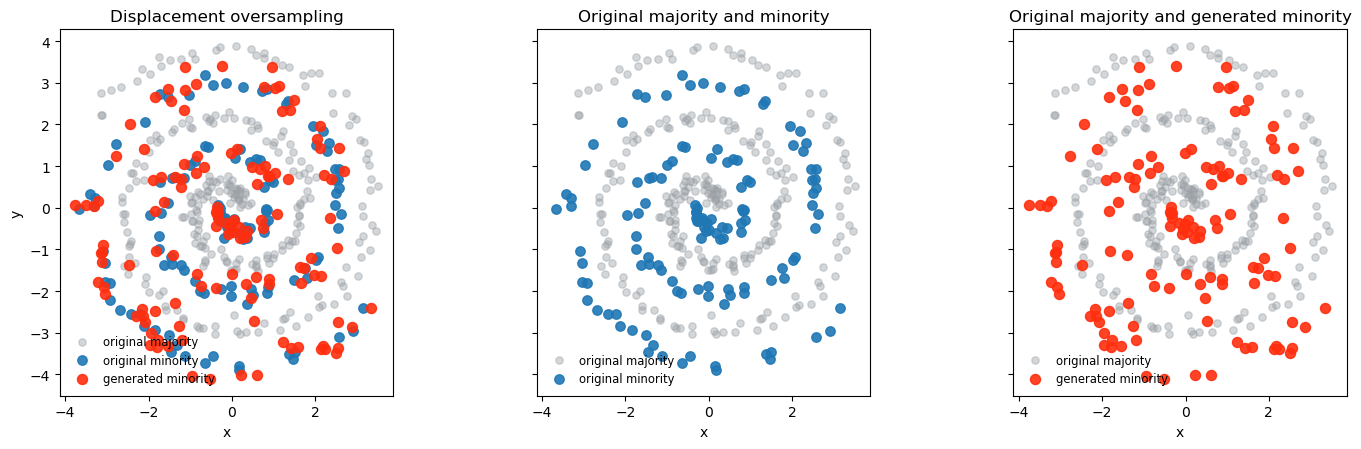

In [4]:
fig, ax = plot_oversampling(df, minority_synthetic)


## Identity-space configurable baseline

Set the full MIMIC estimator here with `mode="identity"` to generate in the preprocessed original feature space.

,method,neighbour_mode,n_neighbors,lambda_range,n_generated,trace_rows,x_min,x_max,y_min,y_max
0,displacement,mutual,5,"(0.25, 0.75)",125,125,-3.926848,3.325296,-3.653332,3.293510


,x,y,label
0,-3.123998,-1.565269,minority
1,-3.323247,-0.937588,minority
2,-3.175652,-1.313234,minority
3,-0.222088,-0.126378,minority
4,-0.954885,1.235836,minority
5,-1.089171,-1.940325,minority
6,0.991061,0.323475,minority
7,0.662221,3.098248,minority


,trace_type,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,condition,decoder,generation_decode_mode,resolved_generation_decode_mode,random_state
0,embedding,0,displacement,354,355,353,0.399246,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
1,embedding,1,displacement,351,354,353,0.550050,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
2,embedding,2,displacement,351,350,351,0.343951,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
3,embedding,3,displacement,256,257,258,0.578717,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
4,embedding,4,displacement,288,291,288,0.325031,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
5,embedding,5,displacement,304,306,304,0.461392,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
6,embedding,6,displacement,277,278,274,0.733718,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2
7,embedding,7,displacement,335,334,335,0.343626,mutual,basic,"{""label"": ""minority""}",IdentityDecoder,auto,direct,2


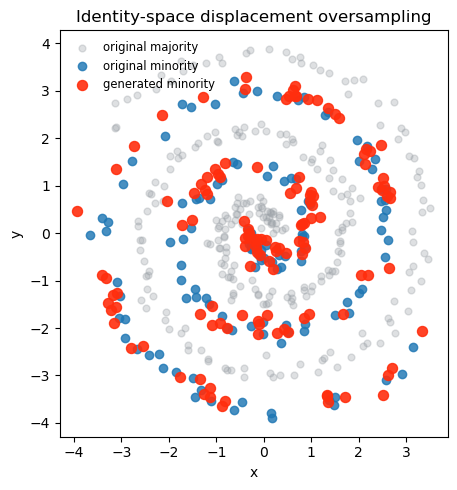

In [5]:
identity_mimic = MIMIC(
    columns={
        "ignore": ["id"],
        "regression": ["x", "y"],
        "classification": ["label"],
    },
    # modes: "identity", "direct", "factorised", "joint"
    mode="identity",
    capacity=0.0,
    random_state=2,
)

identity_summary, identity_synthetic, identity_trace, identity_fig, identity_ax = identity_generation_plot(
    identity_mimic,
    df,
    n_samples=minority_needed,
    condition={"label": "minority"},
    title="Identity-space displacement oversampling",
)

display(identity_summary.style.set_caption("Identity-space generation summary"))
display(identity_synthetic.head(8).style.set_caption("Identity-space synthetic minority rows"))
display(identity_trace.head(8).style.set_caption("Identity-space generation trace"))